# import

In [1]:
import sys
sys.path.append('..')
import numpy as np
from StatTools.generators.ndfnoise_generator import ndfnoise
# from StatTools.generators.multi_scale_fractional_generator import MultiScaleFractionalGenerator
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

from collections import defaultdict
from typing import Optional, Union, Tuple

import numpy as np
from synth import gen_traj, postprocess_collisions, draw_ants_with_direction, draw_traj, build_visible_gt
from nmot import NMOT
from eval import evaluate_mot

# gen vids

/home/akhiyarov/.local/lib/python3.12/site-packages/StatTools/generators/ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))


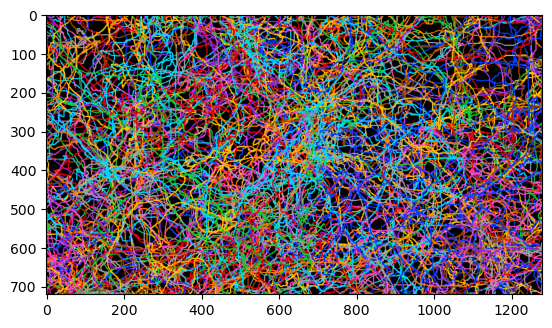

In [9]:
np.random.seed(42)
config = {
'frame_num' : 2000,
# 'frame_shape' : (720, 1280),
'frame_shape' : (720, 1280),
'margin': 100,
'hurst_move': 1.2,
'hurst_species': 0.5,
'ants_num' : 300,
'start_point' : None
}
trajectories = gen_traj(**config)
traj_fixed = postprocess_collisions(
    trajectories,
    radii=4.0,
    max_iter=8,
    substeps=1,
    seed=42,
)
# out_of_bounds = ((traj_fixed <= config['frame_shape'][::-1]).all(axis=-1)) & ((traj_fixed >= 0).all(axis=-1))
# out_of_bounds = np.expand_dims(out_of_bounds, axis=2).repeat(2, axis=2)

# trajectories_cut = np.where(out_of_bounds, traj_fixed, np.nan)
draw_traj(traj_fixed, config['frame_shape'], config['ants_num'], palette='bright')


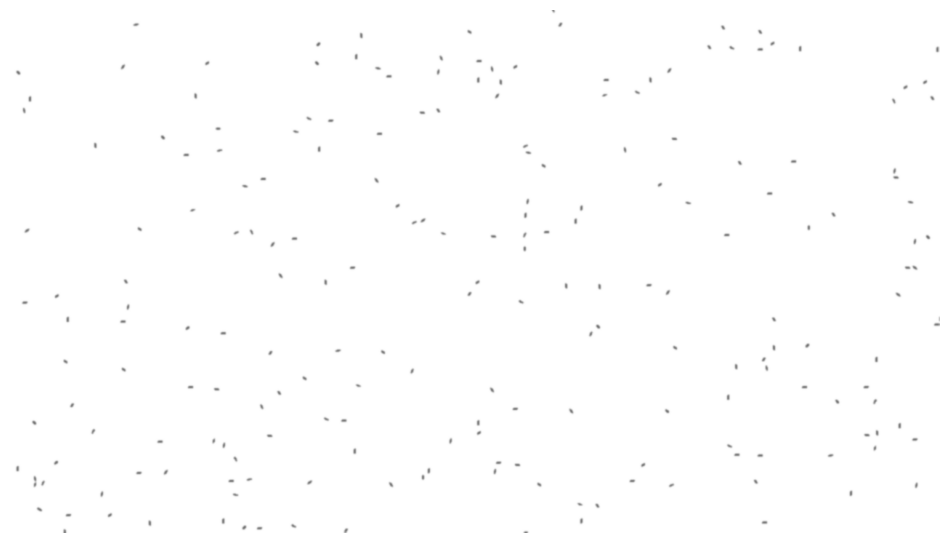

In [ ]:
draw_ants_with_direction(traj_fixed,
                        output_path='../data/collision_model_ants.mp4',
                        frame_num=config['frame_num'],
                        ants_num=config['ants_num'],
                        frame_shape=config['frame_shape'],
                        ant_length=3,
                        ant_width=1,
                        smooth_window=7,
                        imshow=False)

gt_df = build_visible_gt(
    trajectories=traj_fixed,
    frame_shape=config["frame_shape"],
    border_margin=0.0,
    min_visible_frames=1,
    first_id=1,
)

gt_df.to_csv("../data/collision_model_ants_gt.csv", index=False)

# track vids

In [16]:
def process_video(
    input_path: str,
    output_path: str = "tracked_output.mp4",
    csv_path: str = "tracks.csv",
    imshow=True,
    roi=None,
    dist2Threshold=50,
    knn_history = 100,
    pred_head = 'kalman',
    warmup_frames = 50
):
    cap = cv.VideoCapture(input_path)

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {input_path}")

    fps = cap.get(cv.CAP_PROP_FPS)
    width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    if output_path is not None:
        fourcc = cv.VideoWriter_fourcc(*"mp4v")
        writer = cv.VideoWriter(output_path, fourcc, fps, (width, height))

    tracker = NMOT(
        warmup_frames=warmup_frames,
        dist2Threshold=dist2Threshold,
        knn_history=knn_history,
        min_area=8,
        max_area=80,
        max_match_dist=25,
        max_missed=12,
        pred_head=pred_head,
        roi=roi,
    )

    while True:
        ok, frame = cap.read()

        if not ok:
            break

        vis, mask, active_tracks = tracker.update(frame)
        if output_path is not None: 
            writer.write(vis)

        if imshow:
            # cv2.imshow('frame', frame)
            fig, ax = plt.subplots(nrows=2)
            fig.set_size_inches((20, 10))
            
            ax[0].imshow(vis)
            ax[1].imshow(mask)
            
            plt.show()
            
            clear_output(wait=True)
            if cv.waitKey(1) & 0xFF == 27:
                cv.destroyAllWindows()
                if output_path:
                    writer.release()
                break

    cap.release()
    if output_path is not None: 
        writer.release()
    cv.destroyAllWindows()
    if csv_path:
        df = tracker.save_tracks(csv_path)

    return df

In [17]:
df_lk = process_video(input_path='../data/collision_model_ants.mp4',
                   output_path=None,
                  csv_path='../data/collision_model_ants_lk.csv',
                  dist2Threshold=200,
                  knn_history = 200,
                  imshow=False,
                  pred_head='lucas-kanade')

In [18]:
df_kalman = process_video(input_path='../data/collision_model_ants.mp4',
                   output_path=None,
                  csv_path='../data/collision_model_ants_kalman.csv',
                  dist2Threshold=200,
                  knn_history = 200,
                  imshow=False,
                  pred_head='kalman')

In [19]:
df_zero = process_video(input_path='../data/collision_model_ants.mp4',
                   output_path=None,
                  csv_path='../data/collision_model_ants_zero.csv',
                  dist2Threshold=200,
                  knn_history = 200,
                  imshow=False,
                  pred_head=None)

# eval

In [20]:
from pathlib import Path

gt_path = Path('../data/collision_model_ants_gt.csv')
pred_path_kalman = Path('../data/collision_model_ants_kalman.csv')
pred_path_lk = Path('../data/collision_model_ants_lk.csv')
pred_path_zero = Path('../data/collision_model_ants_zero.csv')
gt = pd.read_csv(gt_path)
gt = gt.rename(columns={'ant_id':'track_id'})
gt = gt[gt.frame >= 50]

In [21]:
pred_kalman = pd.read_csv(pred_path_kalman)
pred_lk = pd.read_csv(pred_path_lk)
pred_zero = pd.read_csv(pred_path_zero)
summary_kalman, accumulator = evaluate_mot(gt, pred_kalman, distance_threshold=3.0)
summary_lk, accumulator = evaluate_mot(gt, pred_lk, distance_threshold=3.0)
summary_zero, accumulator = evaluate_mot(gt, pred_zero, distance_threshold=3.0)

In [22]:
metrics_df = pd.concat([summary_zero.T, summary_kalman.T, summary_lk.T], axis=1)
metrics_df.columns = ['zero', 'kalman', 'lucas-kanade']

In [23]:
metrics_df

,zero,kalman,lucas-kanade
num_frames,1950.000000,1950.000000,1950.000000
num_objects,281043.000000,281043.000000,281043.000000
num_predictions,289631.000000,289711.000000,288354.000000
num_matches,269699.000000,271259.000000,271788.000000
num_misses,10460.000000,9038.000000,8638.000000
num_false_positives,19048.000000,17706.000000,15949.000000
num_switches,884.000000,746.000000,617.000000
mostly_tracked,585.000000,588.000000,586.000000
partially_tracked,12.000000,9.000000,11.000000
mostly_lost,0.000000,0.000000,0.000000


In [24]:
# metrics_df.to_csv('../data/metrics_df.csv')